# Data Loading and Augmentation Using Keras

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 1

**Objective:** Build a custom Keras data generator for on-the-fly loading
and augmentation of the agricultural / non-agricultural satellite tile
dataset, then compare against Keras' built-in tooling.


## 1. Import libraries and packages

In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)


I0000 00:00:1782927174.731599     572 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782927175.615903     572 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782927179.233884     572 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


## 2. Locate the dataset

In [2]:
dir_non_agri = './images_dataSAT/class_0_non_agri/'
dir_agri = './images_dataSAT/class_1_agri/'

assert os.path.isdir(dir_non_agri) and os.path.isdir(dir_agri), \
    "images_dataSAT/ with both class folders must be present."


### Task 1: Create `all_image_paths` -- paths of files from both `class_0_non_agri` and `class_1_agri`

In [3]:
all_image_paths = (
    [os.path.join(dir_non_agri, f) for f in os.listdir(dir_non_agri)] +
    [os.path.join(dir_agri, f) for f in os.listdir(dir_agri)]
)

print(f"Total image paths: {len(all_image_paths)}")
print("Sample paths:", all_image_paths[:2])


Total image paths: 6000
Sample paths: ['./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_7594.jpg', './images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_8745.jpg']


### Task 2: Create `temp` by binding image paths and labels using `zip`, then randomly select and print 5 samples

In [4]:
all_labels = (
    [0] * len(os.listdir(dir_non_agri)) +
    [1] * len(os.listdir(dir_agri))
)

temp = list(zip(all_image_paths, all_labels))
print(f"temp created: {len(temp)} (path, label) pairs")

print("\n5 randomly selected (path, label) samples from temp:")
for path, label in random.sample(temp, 5):
    print(f"  label={label} -> {path}")


temp created: 6000 (path, label) pairs

5 randomly selected (path, label) samples from temp:
  label=1 -> ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_12465.jpg
  label=0 -> ./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_6824.jpg
  label=0 -> ./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_1799.jpg
  label=0 -> ./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_22997.jpg
  label=0 -> ./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_13100.jpg


`temp` itself is left in its original (unshuffled) order above, as
created directly from `zip(all_image_paths, all_labels)`. For the batch
generation and train/validation split below, we shuffle a separate
working copy -- this avoids feeding the generator batches drawn only
from one class at a time, since `all_image_paths` lists every
non-agricultural path before every agricultural path.


In [5]:
shuffled_temp = temp.copy()
random.shuffle(shuffled_temp)
print(f"shuffled_temp ready: {len(shuffled_temp)} pairs (temp itself is unchanged)")


shuffled_temp ready: 6000 pairs (temp itself is unchanged)


### Task 3: Generate a data batch (batch size = 8) using `custom_data_generator`

In [6]:
def custom_data_generator(data, batch_size=8, target_size=(64, 64), augment=False):
    """Custom Keras-style generator: yields (images, labels) batches, loading
    and (optionally) augmenting images on the fly from a list of (path, label)
    tuples.
    """
    n = len(data)
    idx = 0
    while True:
        if idx >= n:
            idx = 0
            random.shuffle(data)
        batch = data[idx: idx + batch_size]
        images = np.zeros((len(batch), *target_size, 3), dtype=np.float32)
        labels = np.zeros((len(batch),), dtype=np.float32)
        for i, (path, label) in enumerate(batch):
            img = keras.utils.load_img(path, target_size=target_size)
            arr = keras.utils.img_to_array(img) / 255.0
            if augment:
                if random.random() < 0.5:
                    arr = np.fliplr(arr)
                if random.random() < 0.5:
                    arr = np.flipud(arr)
            images[i] = arr
            labels[i] = label
        idx += batch_size
        yield images, labels


train_gen = custom_data_generator(shuffled_temp, batch_size=8, augment=True)
batch_images, batch_labels = next(train_gen)

print(f"Batch images shape: {batch_images.shape}")
print(f"Batch labels: {batch_labels}")


Batch images shape: (8, 64, 64, 3)
Batch labels: [1. 1. 0. 1. 1. 1. 1. 1.]


### Task 4: Create validation data using a batch size of 8

In [7]:
# Hold out 20% of `shuffled_temp` as validation data, using the same
# generator design but without augmentation.
split_idx = int(0.8 * len(shuffled_temp))
train_data = shuffled_temp[:split_idx]
val_data = shuffled_temp[split_idx:]

val_gen = custom_data_generator(val_data, batch_size=8, augment=False)
val_batch_images, val_batch_labels = next(val_gen)

print(f"Training samples: {len(train_data)}, Validation samples: {len(val_data)}")
print(f"Validation batch images shape: {val_batch_images.shape}")
print(f"Validation batch labels: {val_batch_labels}")


Training samples: 4800, Validation samples: 1200
Validation batch images shape: (8, 64, 64, 3)
Validation batch labels: [1. 0. 0. 0. 0. 0. 1. 0.]


## 3. Visualize a batch from the custom generator

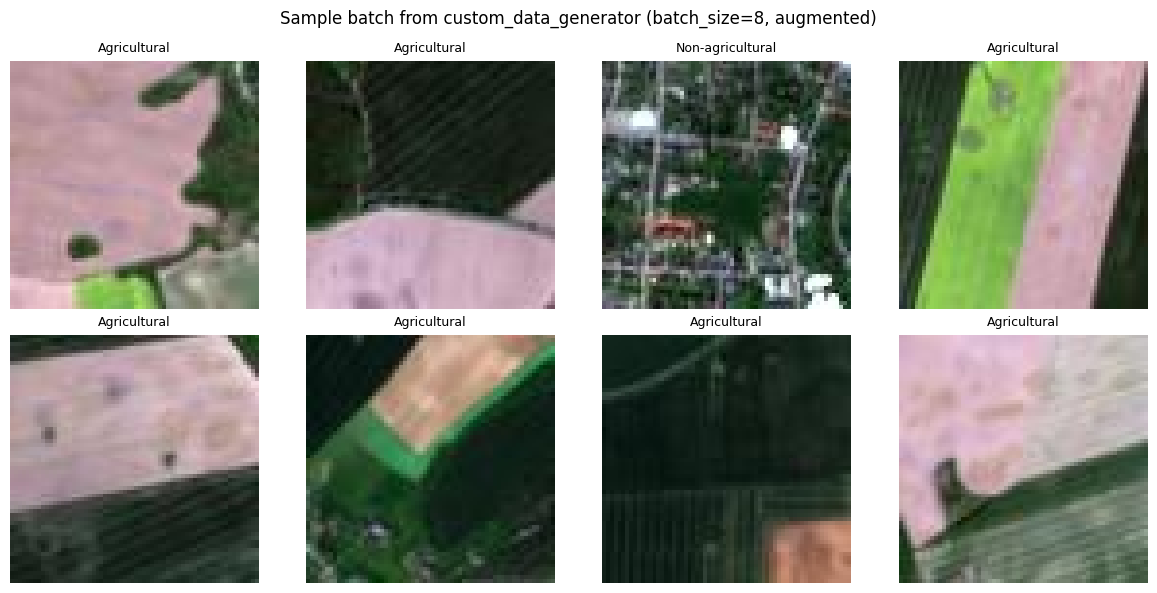

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label in zip(axes.flat, batch_images, batch_labels):
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title("Agricultural" if label == 1 else "Non-agricultural", fontsize=9)
    ax.axis("off")
plt.suptitle("Sample batch from custom_data_generator (batch_size=8, augmented)")
plt.tight_layout()
plt.show()


## 4. Keras built-in utility: `image_dataset_from_directory`

For comparison, Keras' built-in loading + `tf.data` pipeline handles
parallel I/O, caching, and prefetching automatically -- the recommended
approach for production use.


In [9]:
batch_size = 8
img_size = (64, 64)

train_ds = keras.utils.image_dataset_from_directory(
    "images_dataSAT", labels="inferred", label_mode="binary",
    image_size=img_size, batch_size=batch_size,
    validation_split=0.2, subset="training", seed=SEED,
)
val_ds = keras.utils.image_dataset_from_directory(
    "images_dataSAT", labels="inferred", label_mode="binary",
    image_size=img_size, batch_size=batch_size,
    validation_split=0.2, subset="validation", seed=SEED,
)

print("Class names:", train_ds.class_names)


Found 6000 files belonging to 2 classes.


Using 4800 files for training.


Found 6000 files belonging to 2 classes.


Using 1200 files for validation.


Class names: ['class_0_non_agri', 'class_1_agri']


## Summary

A custom Keras data generator (`custom_data_generator`) was built to
understand the mechanics of on-the-fly image loading, labelling, batching,
and augmentation. We then compared it against Keras' built-in
`image_dataset_from_directory` + `tf.data` pipeline, which is the
preferred, production-ready approach for real projects.
